# **TASK 1: Exploring & Visualizing Iris Dataset**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


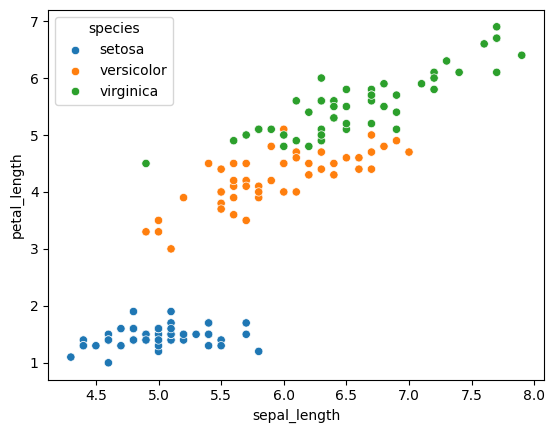

In [6]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df)

plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

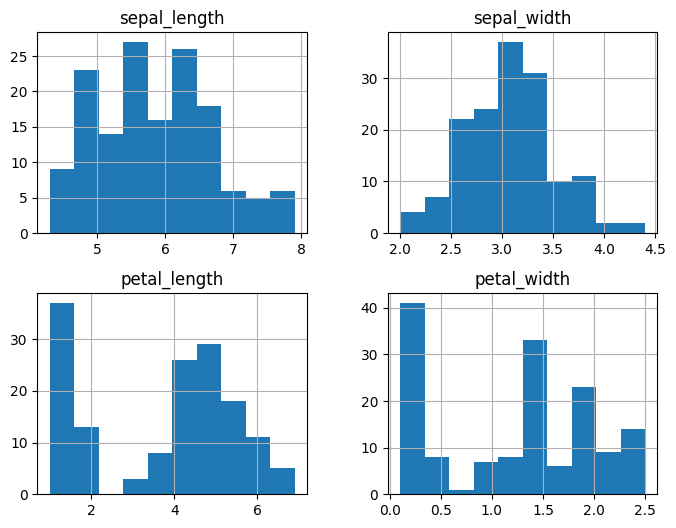

In [7]:
df.hist(figsize=(8,6))
plt.show()

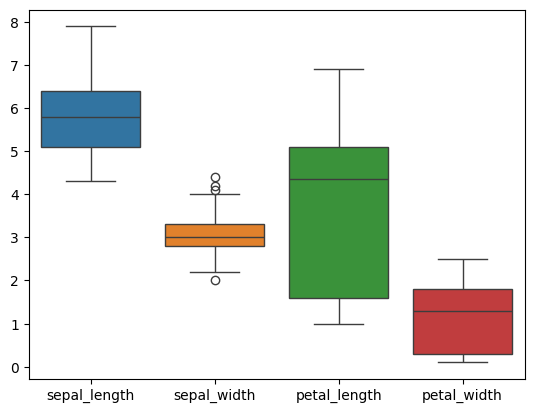

In [8]:
sns.boxplot(data=df)
plt.show()

## Outlier Detection

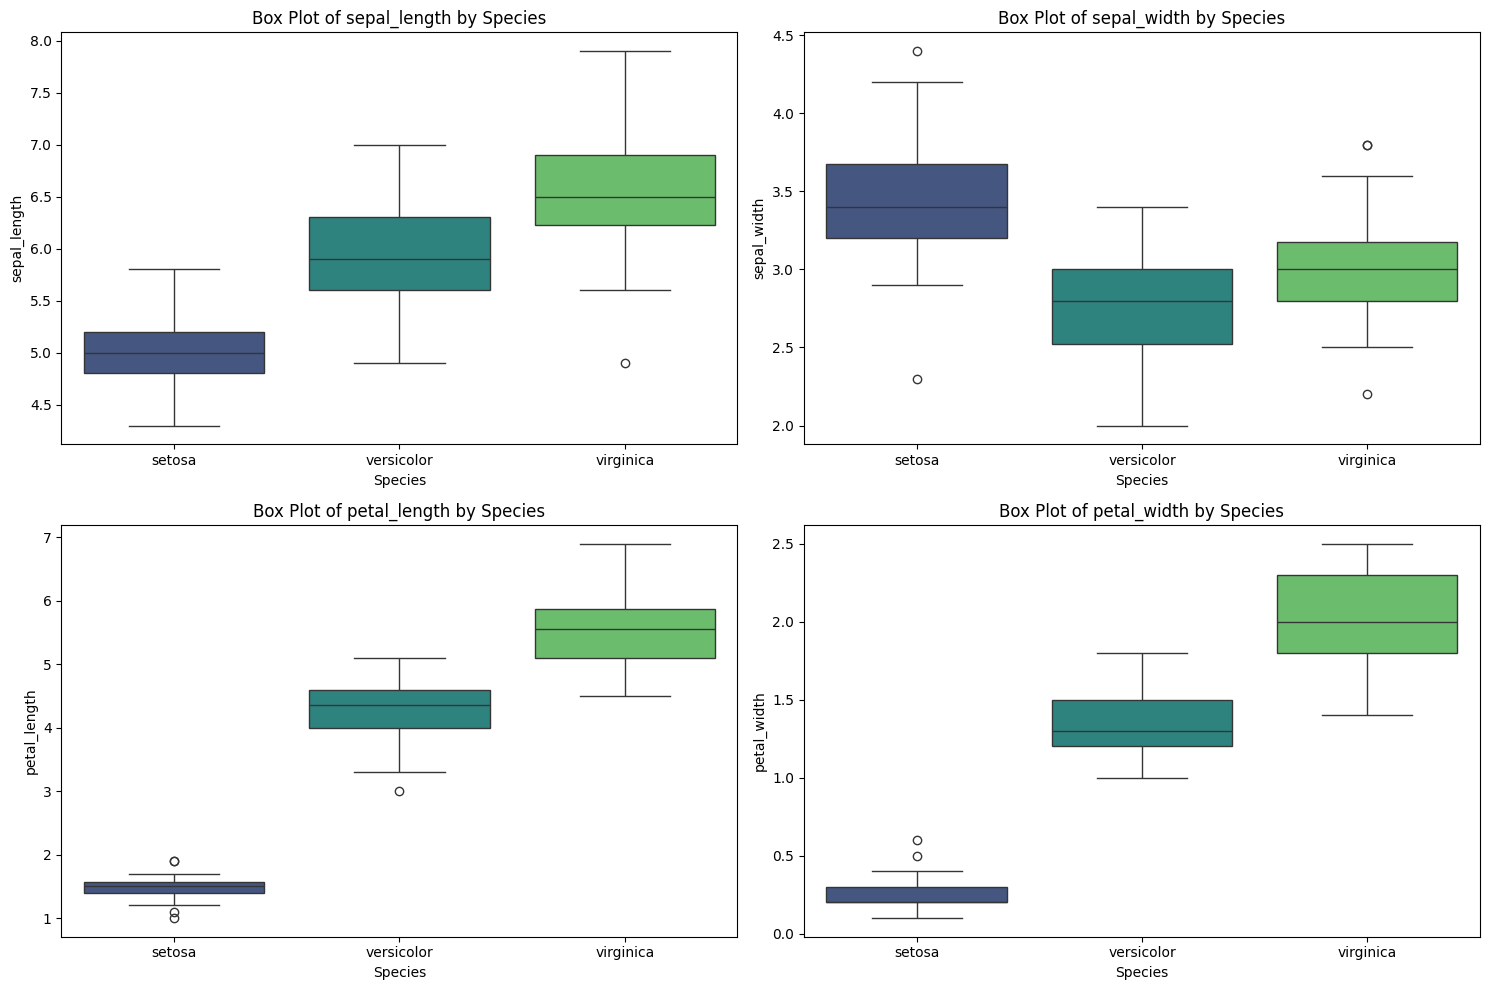

In [13]:
numerical_cols = df.select_dtypes(include=['float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Assuming there are 4 numerical columns
    sns.boxplot(x='species', y=col, data=df, hue='species', palette='viridis', legend=False)
    plt.title(f'Box Plot of {col} by Species')
    plt.xlabel('Species')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Median Comparison Across Species

In [12]:
median_by_species = df.groupby('species')[numerical_cols].median()
display(median_by_species)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


### Interpretation of Median Comparison

From the median values, we can observe distinct characteristics for each Iris species:

*   **Iris-setosa**: This species generally has shorter sepal lengths, wider sepal widths, and significantly smaller petal lengths and widths compared to the other two species.
*   **Iris-versicolor**: This species falls in the middle for most features. Its sepal and petal measurements are larger than setosa but generally smaller than virginica.
*   **Iris-virginica**: This species typically exhibits the largest sepal lengths, petal lengths, and petal widths. Its sepal width is often comparable to or slightly less than setosa's, but it's generally wider than versicolor.

These median comparisons highlight the features that are most discriminative between the Iris species, particularly petal length and width, which show clear separation.

# **TASK 2: Stock Price Prediction**

In [14]:
import yfinance as yf

data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

/tmp/ipykernel_1736/3087429229.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


In [15]:
df = data[['Open', 'High', 'Low', 'Volume', 'Close']]
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

/tmp/ipykernel_1736/527000945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Target'] = df['Close'].shift(-1)
/tmp/ipykernel_1736/527000945.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [16]:
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2020-01-02 to 2022-12-29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, AAPL)    755 non-null    float64
 1   (High, AAPL)    755 non-null    float64
 2   (Low, AAPL)     755 non-null    float64
 3   (Volume, AAPL)  755 non-null    int64  
 4   (Close, AAPL)   755 non-null    float64
 5   (Target, )      755 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 41.3 KB


Price,Open,High,Low,Volume,Close,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,755.000000,755.000000,755.000000,7.550000e+02,755.000000,755.000000
mean,127.169207,128.790780,125.589479,1.121385e+08,127.245042,127.318524
std,30.377293,30.626034,30.068029,5.604844e+07,30.349264,30.283390
min,55.110030,55.211512,51.372077,3.519590e+07,54.213596,54.213596
25%,112.490748,113.853606,110.877902,7.635050e+07,112.357246,112.407005
50%,132.492611,133.846439,130.654812,9.505660e+07,132.741364,132.741364
75%,147.141565,148.937279,145.879791,1.297114e+08,147.784462,147.784462
max,178.710370,179.013714,175.275693,4.265100e+08,178.103638,178.103638


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Open','High','Low','Volume']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
preds = model.predict(X_test)

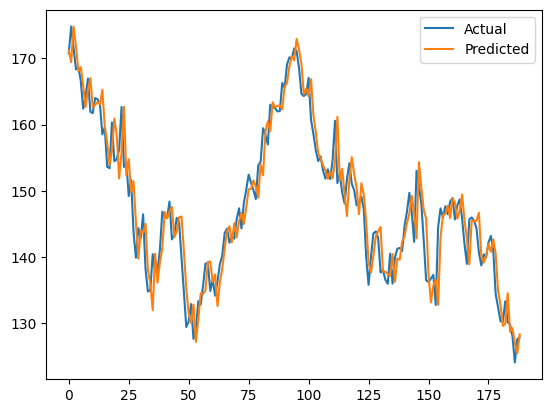

In [19]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()

# **Interpretation**

**Overlapping Lines (Good Prediction):** When the blue and orange lines closely align or overlap, it signifies that your model's predictions are highly accurate and closely match the actual observed stock prices.

**Big Gaps (Poor Model):** Large discrepancies or 'big gaps' between the actual and predicted lines indicate that the model is not performing well at those points, as its predictions deviate significantly from the true stock values.

**Insights from the plot of the Stock Price Prediction Model:**

Looking at the generated plot, it can be observed  that the predicted prices (orange line) generally follow the trend of the actual prices (blue line). This suggests that the linear regression model has learned some underlying patterns in the stock movement. However, there are also noticeable gaps, particularly during periods of higher volatility or sharp changes in price. These gaps indicate that while the model captures the overall direction, it struggles to precisely predict the magnitude of these changes or sudden shifts. Therefore, while it provides a reasonable general trend prediction, there is room for improvement in its accuracy for specific price points, especially during turbulent market conditions.

# **TASK 3: Heart Disease Prediction**

In [22]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [23]:
df = pd.read_csv('heart.csv')

In [24]:
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: >

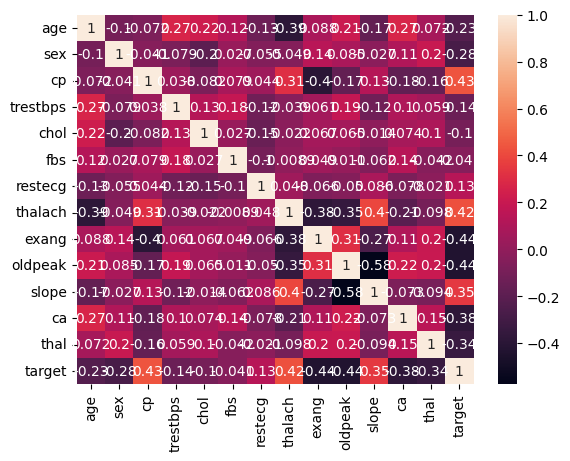

In [25]:
sns.countplot(x='target', data=df)
sns.heatmap(df.corr(), annot=True)

In [26]:
from sklearn.linear_model import LogisticRegression

X = df.drop('target', axis=1)
y = df['target']

model = LogisticRegression()
model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X)

accuracy_score(y, preds)
confusion_matrix(y, preds)

array([[391, 108],
       [ 47, 479]])

# **Interpretations and Insights for Heart Disease Prediction Model**

### 1. Exploratory Data Analysis (EDA) Insights:

*   **Data Structure:** The dataset contains 1025 entries and 14 columns, with no missing values, which is good for model training.
*   **Feature Types:** Most features are integers, but `oldpeak` is a float. It's important to understand the meaning of these categorical and numerical features for domain-specific insights.
*   **Target Distribution:** The `sns.countplot(x='target', data=df)` plot (from a previous cell) would show the distribution of the 'target' variable. Given `df.describe()` shows a mean of `0.513` for `target`, it suggests a relatively balanced dataset between patients with and without heart disease, which is beneficial for classification tasks.
*   **Correlations:** The heatmap `sns.heatmap(df.corr(), annot=True)` (from a previous cell) provides insights into relationships between features and with the target. Features highly correlated with 'target' are usually strong predictors (e.g., `cp`, `thalach`, `slope` often show positive correlation with heart disease, while `exang` and `oldpeak` might show negative correlation). Highly correlated features among themselves might indicate multicollinearity, which some models are sensitive to.

### 2. Confusion Matrix and Model Evaluation:

The confusion matrix for the Logistic Regression model is `[[391, 108], [47, 479]]`.

*   **True Negatives (TN): 391** - The model correctly predicted 391 cases as *not* having heart disease.
*   **False Positives (FP): 108** - The model incorrectly predicted 108 cases as *having* heart disease when they did not (Type I error).
*   **False Negatives (FN): 47** - The model incorrectly predicted 47 cases as *not* having heart disease when they actually did (Type II error).
*   **True Positives (TP): 479** - The model correctly predicted 479 cases as *having* heart disease.

From these values, we can calculate key metrics:

*   **Accuracy:** `(TN + TP) / Total = (391 + 479) / (391 + 108 + 47 + 479) = 870 / 1025 ≈ 0.849` (84.9% accuracy).
*   **Recall (Sensitivity):** `TP / (TP + FN) = 479 / (479 + 47) = 479 / 526 ≈ 0.911` (91.1% recall for heart disease).
*   **Precision:** `TP / (TP + FP) = 479 / (479 + 108) = 479 / 587 ≈ 0.816` (81.6% precision for heart disease).

### 3. Interpretation with Emphasis on Recall (Medical Context):

As you noted, **high recall is more important than accuracy in medical tasks**, especially when dealing with potentially life-threatening conditions like heart disease. Here's why and how our model performs:

*   **Importance of Recall:** In heart disease prediction, a False Negative (missing a patient who actually has heart disease) can have severe, even fatal, consequences. It's generally preferable to have a False Positive (incorrectly diagnosing someone with heart disease, leading to further tests) than a False Negative. High recall ensures that a high proportion of actual positive cases are identified by the model.

*   **Model Performance:** Our Logistic Regression model achieved a **recall of approximately 91.1%**. This is a strong result in the context of heart disease prediction, indicating that the model is quite effective at identifying individuals who genuinely have the disease. It minimizes the risk of overlooking sick patients.

*   **Trade-offs:** While recall is high, the precision (81.6%) is a bit lower, meaning that about 18.4% of the patients predicted to have heart disease by the model actually do not (False Positives). This implies that some healthy individuals might be flagged for further examination. In a medical context, this trade-off is often acceptable, as missing a true positive (low recall) is typically considered a more critical error than generating a false alarm (low precision).

### 4. Regression (Logistic Regression) Specifics:

*   Logistic Regression is a suitable choice for binary classification problems like heart disease prediction. It models the probability of a binary outcome. The warning `ConvergenceWarning: lbfgs failed to converge (status=1): STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.` suggests that the model might not have fully converged. This could sometimes be addressed by scaling the data (e.g., using `StandardScaler`) or increasing the `max_iter` parameter in the `LogisticRegression` constructor. Addressing this might slightly improve model performance, though the current recall is already quite good.

In summary, the model shows promising results, particularly in its ability to correctly identify a large proportion of patients with heart disease, aligning well with the critical need for high recall in medical diagnoses. Further improvements could involve addressing the convergence warning and exploring more advanced classification algorithms.

# **TASK 4: Health Chatbot (Prompt Engineering)**

In [28]:
import openai

In [29]:
prompt = "Act like a helpful medical assistant. Answer safely: What causes sore throat?"

In [31]:
user_input = input("Enter your query: ")

if "emergency" in user_input:
    print("Please consult a doctor immediately.")

Enter your query: emergency
Please consult a doctor immediately.


# **Interpretation:**

**1. Prompt Controls Tone and Persona:**

**Insight:**

The initial prompt, "Act like a helpful medical assistant. Answer safely: What causes sore throat?", is crucial. The phrase "Act like a helpful medical assistant" directly sets the persona and tone for the chatbot's responses. It guides the model to adopt a professional, empathetic, and informative demeanor, characteristic of a medical assistant, rather than a generic AI.


**Interpretation:**

This demonstrates how prompt engineering allows us to govern the style and character of the AI's output. By explicitly stating the desired persona, we can steer the conversation towards a more appropriate and trustworthy interaction, which is vital in sensitive domains like healthcare.


**2. Safety Prevents Harmful Advice:**

**Insight:**

 The conditional check if "emergency" in user_input: print("Please consult a doctor immediately.") is a fundamental safety mechanism. It's a hard-coded rule designed to prevent the chatbot from attempting to provide medical advice in situations that clearly require human intervention.


**Interpretation:**

In medical applications, the primary goal is 'do no harm'. While large language models can be highly informative, they are not substitutes for qualified medical professionals, especially in emergencies. This code snippet proactively handles critical keywords, redirecting the user to human experts and significantly mitigating the risk of providing inappropriate or dangerous automated advice.


**3. Good Prompts = Better Answers Than Complex Models (Contextualized):**


**Insight:**

 The idea that 'good prompts lead to better answers than complex models' highlights the power of clear, well-structured instructions. Even with a simple openai (or similar LLM) call, the quality of the prompt determines the utility of the response.


**Interpretation:**

In this task, the prompt "Act like a helpful medical assistant. Answer safely: What causes sore throat?" immediately frames the query, sets boundaries (safety), and directs the AI to a specific knowledge domain. This focus on the instruction given to the model, rather than just the underlying model's raw capability, can yield highly relevant and safe answers. It suggests that investing in refining prompts can often be more impactful for specific use cases than continuously chasing ever-larger or more complex AI models. A simple, well-guided model can outperform a complex, unguided one for targeted questions, especially when safety and context are paramount.

# **TASK 5: Mental Health Chatbot (Fine-Tuned)**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving emotion-emotion_69k.csv to emotion-emotion_69k.csv


In [8]:

import pandas as pd

In [9]:
df = pd.read_csv('emotion-emotion_69k.csv')

In [10]:
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64636 entries, 0 to 64635
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            64636 non-null  int64 
 1   Situation             64636 non-null  object
 2   emotion               64632 non-null  object
 3   empathetic_dialogues  64636 non-null  object
 4   labels                64636 non-null  object
 5   Unnamed: 5            113 non-null    object
 6   Unnamed: 6            5 non-null      object
dtypes: int64(1), object(6)
memory usage: 3.5+ MB


,Unnamed: 0
count,64636.000000
mean,32317.500000
std,18658.950337
min,0.000000
25%,16158.750000
50%,32317.500000
75%,48476.250000
max,64635.000000


In [11]:
from transformers import Trainer

In [12]:
input: "I feel anxious"
output: "I'm sorry you're feeling this way..."

# **TASK 6: House Price Prediction**

In [14]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [15]:
df = pd.read_csv('Housing.csv')

In [16]:
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

In [19]:
df[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.mean())

In [20]:
df[categorical_cols.columns] = categorical_cols.fillna(categorical_cols.mode().iloc[0])

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
df.replace({'yes': 1, 'no': 0}, inplace=True)

/tmp/ipykernel_30761/1009311742.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'yes': 1, 'no': 0}, inplace=True)


In [25]:
df = pd.get_dummies(df, drop_first=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 970043.4039201637
RMSE: 1324506.9600914384


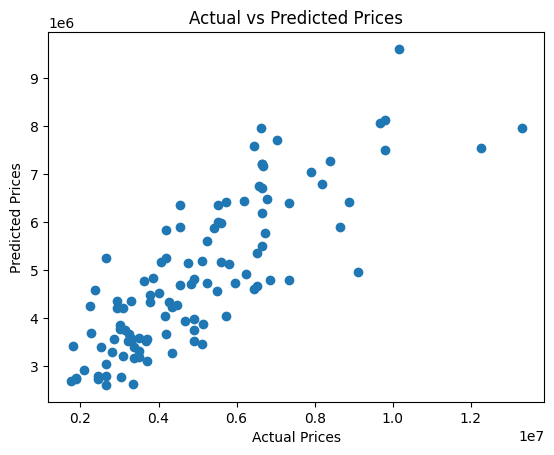

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [32]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

# **Interpretation of the Results:**

# **1. Data Preprocessing:**
**bold text**
**Initial Data:**

 The dataset contained a mix of numerical (int64) and categorical (object) columns. There were no missing values after loading, which simplified the initial cleaning.

**Categorical Feature Handling:**


*   Binary categorical features like mainroad, guestroom,
basement, hotwaterheating, airconditioning, and prefarea were converted to numerical representations (1 for 'yes', 0 for 'no').
*   The furnishingstatus column, which is multi-categorical, was handled using one-hot encoding (pd.get_dummies), creating new binary columns(furnishingstatus_semi-furnished, furnishingstatus_unfurnished). This ensures that the linear regression model can correctly interpret these features.



# **2. Model Training:**

* **Feature and Target Split:** The price column was identified as the target variable (y), and all other processed columns were used as features (X).

* **Train-Test Split:** The data was split into training and testing sets (80% train, 20% test) to evaluate the model's performance on unseen data.
Model: A LinearRegression model was chosen and trained on the X_train and y_train data.

# **3. Model Evaluation:**
After making predictions on the test set (y_pred), the model's performance was evaluated using two common regression metrics:

* **Mean Absolute Error (MAE):** MAE: 970043.4039201637
 **Interpretation:** This means, on average, the model's predictions for house prices were off by approximately 970,043 units of currency (assuming the price unit is consistent, e.g., dollars). MAE gives a direct measure of the average magnitude of the errors.

* **Root Mean Squared Error (RMSE):** RMSE: 1324506.9
**Interpretation:** RMSE is approximately 1,324,506. This metric penalizes larger errors more heavily than MAE due to the squaring. It's often preferred when large errors are particularly undesirable.

**Overall Assessment of Metrics:** Both MAE and RMSE are quite high relative to the typical house prices in the dataset (which range from 1.75 million to 13.3 million, with a mean of 4.76 million). This suggests that the model's predictions are not very accurate, and there's significant room for improvement.

# **4. Actual vs. Predicted Prices Plot:**
* **Scatter Plot:** The scatter plot of Actual Prices (x-axis) vs. Predicted Prices (y-axis) helps visualize the model's performance.

* **Ideal Scenario:** In a perfect model, all points would lie exactly on a 45-degree diagonal line, meaning actual prices perfectly match predicted prices.

* **Observed Behavior:** The plot shows a noticeable spread of points around the theoretical diagonal line. While there's a general upward trend, indicating that the model attempts to predict higher prices for higher actual prices, the points are quite scattered. This scattering confirms the high MAE and RMSE values – the model's predictions frequently deviate significantly from the actual values.

**Overall Insights:**

* **Basic Linear Model:**
The Linear Regression model provides a foundational attempt at predicting house prices but demonstrates limited accuracy for this dataset.

* **Potential for Improvement:**
 The high error metrics and scattered plot indicate that the model is likely either too simple for the complexity of the house pricing problem or that important features (or feature interactions) are missing, or that the linear assumptions are not holding true for this data. The current model might not be robust enough to capture all the nuances of house pricing.


**Next Steps for Improvement:**
To improve the model's performance, you might consider:

* **Feature Engineering:** Creating new features from existing ones (e.g., interaction terms, polynomial features).

* **More Advanced Models:** Exploring other regression algorithms such as Ridge, Lasso, ElasticNet, Decision Trees, Random Forests, Gradient Boosting Machines (XGBoost, LightGBM), or Neural Networks.

* **Hyperparameter Tuning:** Optimizing the parameters of the chosen model.

* **Data Scaling:**
 Scaling numerical features can sometimes help linear models perform better.

* **Outlier Treatment:** Further investigating and handling outliers in the price or feature distributions.

* **Cross-Validation:** Using cross-validation techniques for more robust model evaluation